In [1]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import hls4ml
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects
from hls4ml.model.profiling import numerical
import yaml

2026-06-08 15:19:08.894378: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 15:19:08.911234: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 15:19:09.030082: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 15:19:09.031158: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 15:19:09.549376: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

In [2]:
data = sio.loadmat('../data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

In [ ]:
float_model = load_model("cnn_float.h5")

co = {}
_add_supported_quantized_objects(co)

q_model = load_model(
    "cnn_quant.h5",
    custom_objects=co
)

In [4]:
for layer in float_model.layers:
    print(layer.name)

conv2d_2
conv2d_3
flatten_1
dense_2
dense_3


In [22]:
config_path = "cnn_float.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
    

hls_model = hls4ml.converters.convert_from_keras_model(
    float_model,
    hls_config=config["HLSConfig"],
    output_dir=config["OutputDir"],
    backend=config["Backend"],
    part=config["Part"],
    clock_period=config["ClockPeriod"],
    io_type=config["IOType"],
    project_name=config["ProjectName"],
)

Profiling weights (before optimization)
[{'med': 0.077861376, 'q1': 0.03718951623886824, 'q3': 0.11645527370274067, 'whislo': 5.3676755e-05, 'whishi': 0.23307472, 'layer': 'conv2d_2', 'weight': 'conv2d_2/w'}, {'med': 0.038049243, 'q1': 0.022291951347142458, 'q3': 0.05511832423508167, 'whislo': 0.0021380342, 'whishi': 0.12278704, 'layer': 'conv2d_2', 'weight': 'conv2d_2/b'}, {'med': 0.13621944, 'q1': 0.06591683812439442, 'q3': 0.22124164551496506, 'whislo': 0.00018161947, 'whishi': 0.977436, 'layer': 'conv2d_3', 'weight': 'conv2d_3/w'}, {'med': 0.05267312, 'q1': 0.022154556587338448, 'q3': 0.07634593546390533, 'whislo': 0.003827272, 'whishi': 0.1508792, 'layer': 'conv2d_3', 'weight': 'conv2d_3/b'}, {'med': 0.016198404, 'q1': 0.007974841864779592, 'q3': 0.03528794925659895, 'whislo': 3.5401897e-08, 'whishi': 0.94427353, 'layer': 'dense_2', 'weight': 'dense_2/w'}, {'med': 0.006006565, 'q1': 0.0018947453936561942, 'q3': 0.01646658917888999, 'whislo': 0.00025985754, 'whishi': 0.08065531, 'l

(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

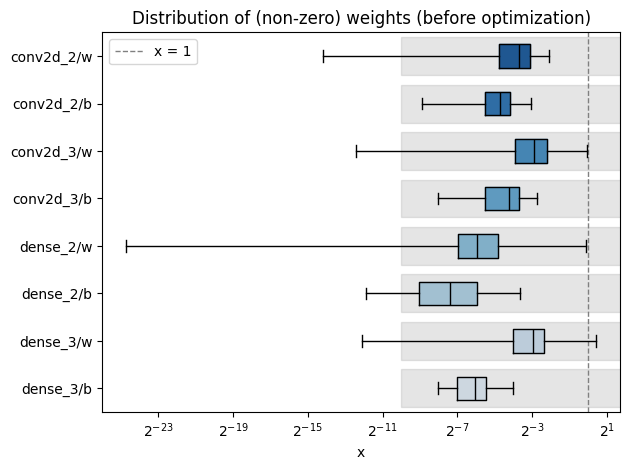

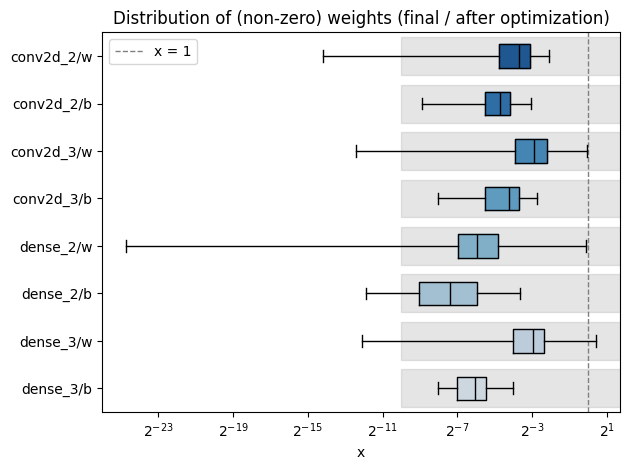

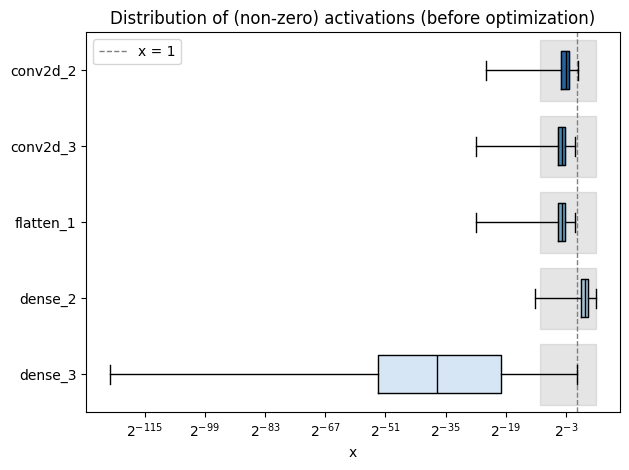

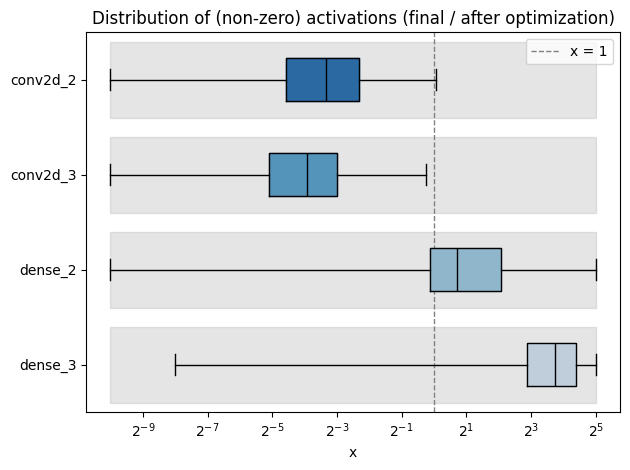

In [23]:
hls4ml.model.profiling.numerical(
    model=float_model,
    hls_model=hls_model,
    X=X_test[:1000]
)

In [24]:
hls_model.write()
hls_model.compile()

In [ ]:
hls_model.build(
        csim=True,
        synth=True,
        cosim=True,
        export=True,
    )


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Thu Jun  4 12:42:55 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/fauri/Documentos/hls4ml/project/notebooks/outputs/cnn_float/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project cnn_float_prj 
INFO: [HLS 200-10] Creating and opening project '/home/fauri/Documentos/hls4ml/project/notebooks/outputs/cnn_float/cnn_float_prj'.
INFO: [HLS 200-1510] Running: set_top cnn_float 
INFO: [HLS 200-1510] Running: add_files firmware/cnn_float.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/cnn_float.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb cnn_float_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'cnn_float_test.cpp' to the project
INFO: [HLS 200-1510] Running: a